In [ ]:
!pip install kagglehub gradio

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import gradio as gr

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.optimizers import Adam

In [ ]:
import kagglehub

path = kagglehub.dataset_download("alxmamaev/flowers-recognition")
DATASET_PATH = os.path.join(path, os.listdir(path)[0])

print("Dataset Path:", DATASET_PATH)

Using Colab cache for faster access to the 'flowers-recognition' dataset.
Dataset Path: /kaggle/input/flowers-recognition/flowers


## Exploratory Data Analysis (EDA)
Quick review of class balance, sample images, size distribution, and augmentation variations.

In [ ]:
from PIL import Image
import glob
import random

class_dirs = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

class_counts = {
    cls: len(glob.glob(os.path.join(DATASET_PATH, cls, "*")))
    for cls in class_dirs
}

print("Classes:", class_dirs)
print("Total images:", sum(class_counts.values()))

plt.figure(figsize=(7, 3))
plt.bar(class_counts.keys(), class_counts.values(), color="#A67A82")
plt.title("Image Count per Class")
plt.ylabel("Images")
plt.xticks(rotation=35, ha="right")
plt.show()


In [ ]:
# Sample images from each class
fig, axes = plt.subplots(1, len(class_dirs), figsize=(14, 3))
for ax, cls in zip(axes, class_dirs):
    images = glob.glob(os.path.join(DATASET_PATH, cls, "*"))
    sample = random.choice(images)
    img = Image.open(sample)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# Image size distribution (sample)
sample_paths = []
for cls in class_dirs:
    paths = glob.glob(os.path.join(DATASET_PATH, cls, "*"))
    sample_paths.extend(random.sample(paths, min(80, len(paths))))

sizes = [Image.open(p).size for p in sample_paths]
widths, heights = zip(*sizes)

plt.figure(figsize=(5, 4))
plt.scatter(widths, heights, alpha=0.3, s=10, color="#8B6B73")
plt.title("Image Size Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()


In [ ]:
# Variations / augmentations preview
sample_class = class_dirs[0]
sample_image = random.choice(glob.glob(os.path.join(DATASET_PATH, sample_class, "*")))
img = tf.keras.preprocessing.image.load_img(sample_image, target_size=(128, 128))
img_arr = tf.keras.preprocessing.image.img_to_array(img)
img_arr = np.expand_dims(img_arr, axis=0)

aug_preview = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
)

aug_iter = aug_preview.flow(img_arr, batch_size=1)
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax in axes.flatten():
    batch = next(aug_iter)[0]
    ax.imshow(batch)
    ax.axis("off")
plt.suptitle("Augmented Variations")
plt.tight_layout()
plt.show()


In [ ]:
# 3. DATA GENERATOR
def load_data():

    train_gen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2,
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.15,
        shear_range=0.1,
        horizontal_flip=True,
    )

    val_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

    train = train_gen.flow_from_directory(
        DATASET_PATH,
        target_size=(128,128),
        batch_size=32,
        subset='training'
    )

    val = val_gen.flow_from_directory(
        DATASET_PATH,
        target_size=(128,128),
        batch_size=32,
        subset='validation'
    )

    return train, val

In [ ]:
from tensorflow.keras.optimizers import Adam, SGD

# MODELS
def build_ann(num_classes):
    model = Sequential([
        Input(shape=(128,128,3)),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

def build_cnn(num_classes):
    model = Sequential([
        Input(shape=(128,128,3)),
        Conv2D(32,(3,3),activation='relu'),
        MaxPooling2D(),
        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(128,activation='relu'),
        Dense(num_classes,activation='softmax')
    ])
    return model

def build_freeze(num_classes):
    base = MobileNet(weights='imagenet', include_top=False, input_shape=(128,128,3))
    for layer in base.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(128, activation='relu')(x)
    out = Dense(num_classes, activation='softmax')(x)

    return Model(base.input, out)

def build_unfreeze(num_classes):
    base = MobileNet(weights='imagenet', include_top=False, input_shape=(128,128,3))

    for layer in base.layers[:-20]:
        layer.trainable = False
    for layer in base.layers[-20:]:
        layer.trainable = True

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(128, activation='relu')(x)
    out = Dense(num_classes, activation='softmax')(x)

    return Model(base.input, out)


# TRAIN MODELS
train, val = load_data()
num_classes = train.num_classes

model_builders = {
    "ANN": build_ann,
    "CNN": build_cnn,
    "Freeze": build_freeze,
    "Unfreeze": build_unfreeze
}

optimizers = {
    "Adam": Adam,
    "SGD": SGD
}

results = {}
models_saved = {}

for model_name, builder in model_builders.items():
    for opt_name, opt_class in optimizers.items():

        print(f"\nTraining: {model_name} + {opt_name}")

        model = builder(num_classes)

        optimizer = opt_class(learning_rate=0.001)

        model.compile(
            optimizer=optimizer,
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            train,
            validation_data=val,
            epochs=3,
            batch_size=32,
            verbose=1
        )

        acc = max(history.history['val_accuracy'])

        key = f"{model_name}_{opt_name}"
        results[key] = acc

        model.save(key + ".h5")
        models_saved[key] = key + ".h5"


# MODERN GRAPH
def plot_results():

    names = list(results.keys())
    values = list(results.values())

    fig, ax = plt.subplots(figsize=(7,4))

    bars = ax.bar(names, values, color='#6366f1')

    ax.set_title("Model Accuracy Comparison")
    ax.set_ylabel("Accuracy")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45)

    best_idx = values.index(max(values))
    bars[best_idx].set_color('#22c55e')

    for i, v in enumerate(values):
        ax.text(i, v, f"{v:.3f}", ha='center')

    return fig


# LOAD MODELS
loaded_models = {
    name: tf.keras.models.load_model(path)
    for name, path in models_saved.items()
}

class_names = list(train.class_indices.keys())


# PREDICTION
def predict(image, model_name):

    img = tf.image.resize(image, (128,128)) / 255.0
    img = np.expand_dims(img, axis=0)

    model = loaded_models[model_name]
    pred = model.predict(img)[0]

    return class_names[np.argmax(pred)], {
        class_names[i]: float(pred[i]) for i in range(len(class_names))
    }


Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.

Training: ANN + Adam
Epoch 1/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 58s 481ms/step - accuracy: 0.3329 - loss: 4.3700 - val_accuracy: 0.3256 - val_loss: 2.0472
Epoch 2/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 38s 346ms/step - accuracy: 0.3868 - loss: 1.9750 - val_accuracy: 0.3616 - val_loss: 1.8820
Epoch 3/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 39s 354ms/step - accuracy: 0.4675 - loss: 1.5132 - val_accuracy: 0.4267 - val_loss: 1.7121



Training: ANN + SGD
Epoch 1/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 221ms/step - accuracy: 0.3437 - loss: 1.4730 - val_accuracy: 0.3791 - val_loss: 1.4226
Epoch 2/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 194ms/step - accuracy: 0.4290 - loss: 1.3379 - val_accuracy: 0.4291 - val_loss: 1.3069
Epoch 3/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 184ms/step - accuracy: 0.4672 - loss: 1.2776 - val_accuracy: 0.4058 - val_loss: 1.3359



Training: CNN + Adam
Epoch 1/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.4553 - loss: 1.3232 - val_accuracy: 0.5616 - val_loss: 1.1107
Epoch 2/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.6176 - loss: 0.9804 - val_accuracy: 0.5477 - val_loss: 1.1112
Epoch 3/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.7278 - loss: 0.7460 - val_accuracy: 0.6023 - val_loss: 1.0583



Training: CNN + SGD
Epoch 1/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 108s 985ms/step - accuracy: 0.3118 - loss: 1.5658 - val_accuracy: 0.2558 - val_loss: 1.5479
Epoch 2/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 107s 979ms/step - accuracy: 0.3746 - loss: 1.4901 - val_accuracy: 0.4105 - val_loss: 1.4560
Epoch 3/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.4249 - loss: 1.4160 - val_accuracy: 0.4314 - val_loss: 1.3866



Training: Freeze + Adam
17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 78s 682ms/step - accuracy: 0.7920 - loss: 0.5867 - val_accuracy: 0.8628 - val_loss: 0.4254
Epoch 2/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 74s 676ms/step - accuracy: 0.9196 - loss: 0.2453 - val_accuracy: 0.8535 - val_loss: 0.4489
Epoch 3/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 74s 681ms/step - accuracy: 0.9540 - loss: 0.1543 - val_accuracy: 0.8477 - val_loss: 0.4844



Training: Freeze + SGD
Epoch 1/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 79s 695ms/step - accuracy: 0.3483 - loss: 1.5534 - val_accuracy: 0.5395 - val_loss: 1.1732
Epoch 2/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 78s 657ms/step - accuracy: 0.6121 - loss: 1.0313 - val_accuracy: 0.6965 - val_loss: 0.8939
Epoch 3/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 75s 693ms/step - accuracy: 0.7165 - loss: 0.8194 - val_accuracy: 0.7453 - val_loss: 0.7628



Training: Unfreeze + Adam
Epoch 1/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.8105 - loss: 0.5539 - val_accuracy: 0.8663 - val_loss: 0.4451
Epoch 2/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9167 - loss: 0.2411 - val_accuracy: 0.7884 - val_loss: 0.8737
Epoch 3/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9604 - loss: 0.1313 - val_accuracy: 0.7953 - val_loss: 0.8966



Training: Unfreeze + SGD
Epoch 1/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.4235 - loss: 1.5249 - val_accuracy: 0.6174 - val_loss: 1.0259
Epoch 2/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.6957 - loss: 0.8418 - val_accuracy: 0.7256 - val_loss: 0.7654
Epoch 3/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.7877 - loss: 0.6405 - val_accuracy: 0.7709 - val_loss: 0.6491


/tmp/ipykernel_2557/2892461695.py:100: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="pink"), css=css) as demo:
/tmp/ipykernel_2557/2892461695.py:100: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="pink"), css=css) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://45ba7aaeb2e02f9236.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


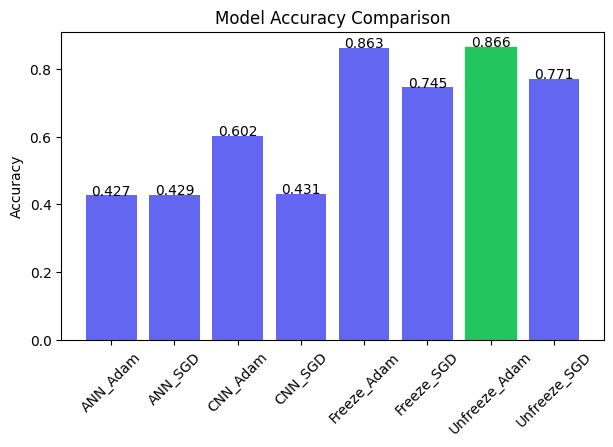

In [ ]:
import gradio as gr

css = """
/* Global Styles */
body {
    background-color: #E0BFB8;
    font-family: 'Inter', sans-serif;
}

/* HEADER */
.header-container {
    text-align: center;
    padding: 35px 20px;
    background: linear-gradient(135deg, #B76E79 0%, #8c4a54 100%);
    color: white;
    border-radius: 18px;
    margin-bottom: 30px;
    border: 1px solid rgba(255,255,255,0.2);
    box-shadow: 0 10px 25px -5px rgba(183,110,121,0.4);
}

/* FORCE HEADER TEXT WHITE */
.header-container h1,
.header-container p {
    color: white !important;
}

/* CARDS */
.custom-card {
    background: #C5C3C6;
    padding: 24px;
    border-radius: 20px;
    border: 1px solid #b8b6b9;
    box-shadow: 0 2px 10px rgba(0,0,0,0.05);
    margin-bottom: 10px;
    color: #2d2d2d;
}

/* METRICS */
.metric-box {
    text-align: center;
    border-left: 4px solid #B76E79;
    padding-left: 15px;
}

.metric-title {
    color: #555;
    font-size: 0.75rem;
    font-weight: 700;
    text-transform: uppercase;
    letter-spacing: 1px;
}

.metric-value {
    color: #4a2c2f;
    font-size: 1.4rem;
    font-weight: 800;
}

/* BUTTON */
.primary-btn {
    background: linear-gradient(135deg, #B76E79 0%, #8c4a54 100%) !important;
    color: white !important;
    border: none !important;
    font-weight: 700 !important;
    border-radius: 12px !important;
    padding: 12px !important;
    transition: all 0.3s ease !important;
    box-shadow: 0 4px 12px rgba(183,110,121,0.5) !important;
}

.primary-btn:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 6px 15px rgba(183,110,121,0.6) !important;
}

/* INPUTS */
.gradio-container input,
.gradio-container textarea {
    border: 1px solid #b8b6b9 !important;
    border-radius: 10px !important;
}

/* RADIO / ACCENT COLOR FIX */
.gradio-container input[type="radio"]:checked {
    accent-color: #d9a3ab !important;
}

/* RANGE / SLIDER */
.gradio-container input[type="range"] {
    accent-color: #d9a3ab !important;
}

/* GLOBAL ACCENT OVERRIDE (plots, highlights) */
:root {
    --color-accent: #d9a3ab !important;
}
"""

with gr.Blocks(theme=gr.themes.Soft(primary_hue="pink"), css=css) as demo:

    # HEADER
    gr.Markdown("""
    <div class="header-container">
        <h1>Model Comparison Dashboard</h1>
        <p>Deep Learning Evaluation </p>
    </div>
    """)

    # METRICS
    best_model = max(results, key=results.get)
    best_acc = round(results[best_model], 3)

    with gr.Row():
        with gr.Column(elem_classes="custom-card"):
            gr.Markdown(f"""
            <div class="metric-box">
                <div class="metric-title">🏆 Top Model</div>
                <div class="metric-value">{best_model}</div>
            </div>
            """)

        with gr.Column(elem_classes="custom-card"):
            gr.Markdown(f"""
            <div class="metric-box">
                <div class="metric-title">📈 Accuracy</div>
                <div class="metric-value">{best_acc * 100}%</div>
            </div>
            """)

    # MAIN SECTION
    with gr.Row(equal_height=True):

        # INPUT
        with gr.Column():
            with gr.Group(elem_classes="custom-card"):
                gr.Markdown("### 📸 Upload Image")
                img_input = gr.Image(type="numpy")

                gr.Markdown("### ⚙️ Settings")
                model_choice = gr.Radio(
                    choices=list(results.keys()),
                    value=list(results.keys())[0]
                )

                btn = gr.Button("🚀 RUN", elem_classes="primary-btn")

        # OUTPUT
        with gr.Column():
            with gr.Group(elem_classes="custom-card"):
                gr.Markdown("### 🎯 Output")
                output = gr.Textbox(interactive=False)
                confidence = gr.Label()

    # GRAPH
    with gr.Row():
        with gr.Column(elem_classes="custom-card"):
            gr.Markdown("### 📊 Performance")
            gr.Plot(value=plot_results())

    # LOGIC
    btn.click(
        predict,
        inputs=[img_input, model_choice],
        outputs=[output, confidence]
    )

demo.launch()